In [1]:
#Se importan las librerias a ocupar
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
#Cargar el dataset
df = pd.read_csv("netflix_titles.csv")

In [5]:
#Mostrar las primeras filas
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
#Mostrar las dimensiones
df.shape

(8807, 12)

In [8]:
#Mostrar las primeras columnas 
df.columns 

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
#Mostrar tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
#Identificar la cantidad total de valores nulls por cada columna 
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [11]:
#Calcular el porcentaje de valores faltantes 
(df.isnull().sum() / len(df)) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [12]:
#Detectar filas duplicadas
df.duplicated().sum()

np.int64(0)

In [13]:
#Transformación - Estandarizar los nombres de las columnas a minúsculas sin espacio 
df.columns = df.columns.str.strip().str.lower()

In [14]:
#Se eliminan las columnas con mayor valores nulls 
df.drop(columns=["director"], inplace=True)
df.drop(columns=["country"], inplace=True)
df.drop(columns=["cast"], inplace=True)

In [15]:
#Se rellenan las columnas con pocos nulos usando la moda
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

In [17]:
#Comprobar si la cantidad de valores por cada columna es 0
df.isnull().sum()

show_id         0
type            0
title           0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

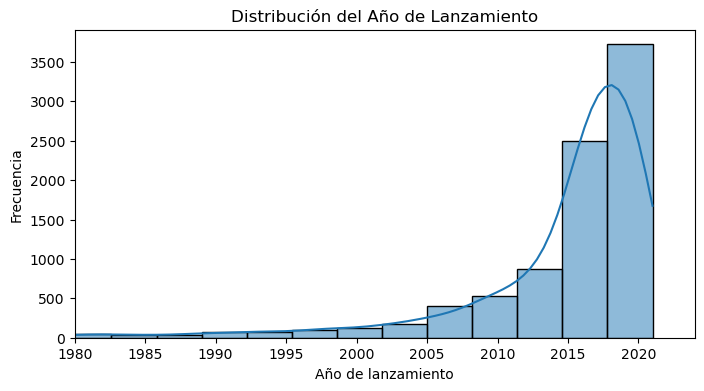

In [18]:
#Gráfica 1 - Histograma de los años de lanzamiento
plt.figure(figsize=(8,4))
sns.histplot(df, x="release_year", bins=30, kde=True)
plt.title("Distribución del Año de Lanzamiento")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Frecuencia")
plt.xlim(1980, 2024) 
plt.show()

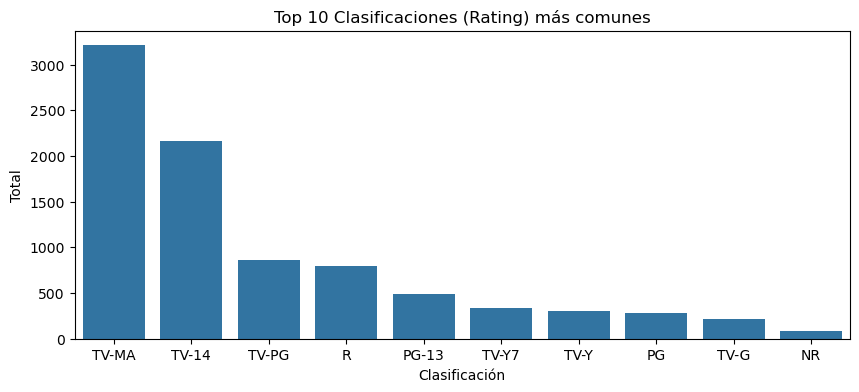

In [19]:
#Gráfica 2 - Top 10 Clasificaciones (Rating) más comunes
plt.figure(figsize=(10,4))
orden_rating = df["rating"].value_counts().index[:10]
sns.countplot(df, x="rating", order=orden_rating)
plt.title("Top 10 Clasificaciones (Rating) más comunes")
plt.xlabel("Clasificación")
plt.ylabel("Total")
plt.show()

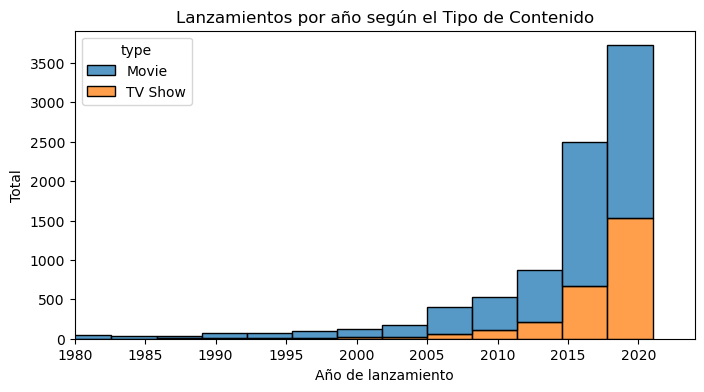

In [20]:
#Gráfica 3 - Año de lanzamiento comparando Películas vs Series
plt.figure(figsize=(8,4))
sns.histplot(df, x="release_year", hue="type", bins=30, multiple="stack")
plt.title("Lanzamientos por año según el Tipo de Contenido")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Total")
plt.xlim(1980, 2024)
plt.show()

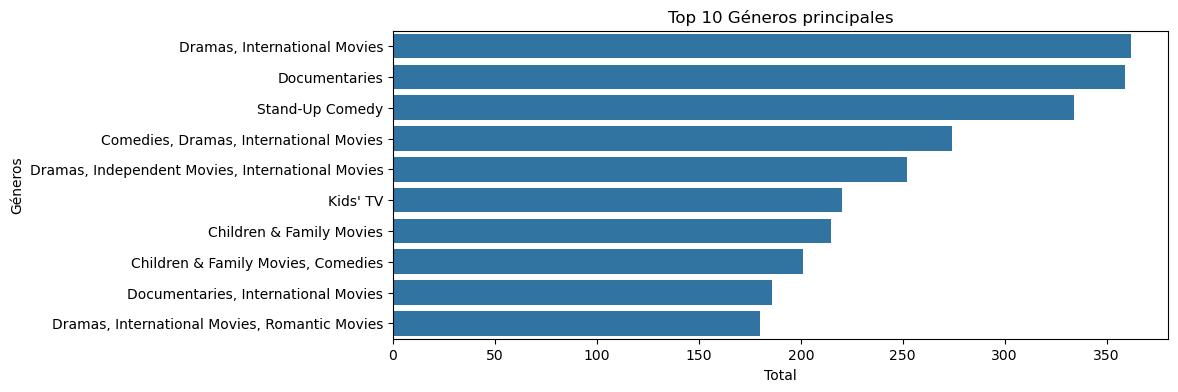

In [21]:
# Gráfica 4 - Top 10 Géneros / Categorías principales
plt.figure(figsize=(10,4))
orden_generos = df["listed_in"].value_counts().index[:10]
sns.countplot(df, y="listed_in", order=orden_generos)
plt.title("Top 10 Géneros principales")
plt.xlabel("Total")
plt.ylabel("Géneros")
plt.show()

In [23]:
#Conclusiones derivadas al análisis

#Preferencia por largometrajes: El catálogo se compone mayoritariamente de películas, superando ampliamente a las series.

#Crecimiento exponencial reciente: Se detecta un "boom" de contenido a partir de 2010 (con un pico entre 2018 y 2020), impulsado por la era del streaming y el contenido original.

#Enfoque en público maduro y juvenil: Las clasificaciones dominantes son para adultos (TV-MA) y mayores de 14 años (TV-14), muy por encima del contenido infantil.

#Concentración geográfica: Estados Unidos e India lideran indiscutiblemente la cantidad de títulos, lo que confirma que la producción y exportación de entretenimiento está fuertemente centralizada.